## Project Scope and Dataset Decision

This project is designed as a **proof-of-concept implementation**, rather than a clinically meaningful predictive model.

Because whole-slide images (WSIs) are extremely large and the primary goal is to demonstrate hands-on experience with **multimodal biomedical data, representation learning, PyTorch, and Transformer-based fusion**, we intentionally use a very small cohort of **three TCGA-BRCA patients**.

The selected patients will provide both **RNA expression data and pathology WSIs**. We will build an end-to-end pipeline:

**RNA + WSI → modality-specific representations → multimodal Transformer → prediction**

The resulting model is **not expected to generalize or produce clinically meaningful performance**. Its purpose is to demonstrate the complete technical workflow and document the practical limitations of working with a very small biomedical dataset.


In [1]:
import requests
import pandas as pd
import json

In [2]:
url = "https://api.gdc.cancer.gov/files"

response = requests.post(
    url,
    headers={"Content-Type": "application/json"}
)

print(response.status_code)

200


In [3]:
filters = {
    "op": "and",
    "content": [
        {
            "op": "=",
            "content": {
                "field": "cases.project.project_id",
                "value": "TCGA-BRCA"
            }
        },
        {
            "op": "=",
            "content": {
                "field": "access",
                "value": "open"
            }
        }
    ]
}

response = requests.post(
    url,
    headers={"Content-Type": "application/json"},
    json={"filters": filters}
)

print(response.status_code)

200


In [4]:
data = response.json()

print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['data', 'warnings'])


In [5]:
data["data"].keys()

dict_keys(['hits', 'pagination'])

In [6]:
data["data"]["pagination"]

{'count': 10,
 'total': 27931,
 'size': 10,
 'from': 0,
 'sort': '',
 'page': 1,
 'pages': 2794}

In [7]:
data["data"]["hits"][0]

{'id': '757ee75b-674e-49a5-8ba0-cc1b574a51ae',
 'data_format': 'TXT',
 'access': 'open',
 'file_name': '31fa9bfd-dc91-4e27-be93-db7df8df2cd8.mirbase21.mirnas.quantification.txt',
 'submitter_id': 'mirna_swap_dr11_1186_MirnaExpression43d41344-73b1-4786-8b53-93e420b61c0b_profiling',
 'data_category': 'Transcriptome Profiling',
 'acl': ['open'],
 'type': 'mirna_expression',
 'platform': 'Illumina',
 'file_size': 50084,
 'created_datetime': '2018-03-20T04:53:45.847187-05:00',
 'md5sum': '8f2fb8583ec2ea249dd11fc3fa5ce78c',
 'updated_datetime': '2024-07-29T18:10:34.696357-05:00',
 'file_id': '757ee75b-674e-49a5-8ba0-cc1b574a51ae',
 'data_type': 'miRNA Expression Quantification',
 'state': 'released',
 'experimental_strategy': 'miRNA-Seq',
 'version': '1',
 'data_release': '12.0 - 46.0'}

In [8]:
fields = [
    "file_id",
    "file_name",
    "data_type",
    "access",
    "cases.case_id",
    "cases.submitter_id"
]

In [9]:
response = requests.post(
    url,
    headers={"Content-Type": "application/json"},
    json={
        "filters": filters,
        "fields": ",".join(fields),
        "size": 100
    }
)

In [10]:
data = response.json()
data["data"]["hits"][0]

{'id': '757ee75b-674e-49a5-8ba0-cc1b574a51ae',
 'cases': [{'case_id': 'dfefb76a-ec6b-4cd2-9d45-2e1e4befc7ea',
   'submitter_id': 'TCGA-A8-A09E'}],
 'access': 'open',
 'file_name': '31fa9bfd-dc91-4e27-be93-db7df8df2cd8.mirbase21.mirnas.quantification.txt',
 'file_id': '757ee75b-674e-49a5-8ba0-cc1b574a51ae',
 'data_type': 'miRNA Expression Quantification'}

In [11]:
hits = data["data"]["hits"]

print(len(hits))

100


In [12]:
df = pd.json_normalize(hits)
df.head()

,id,cases,access,file_name,file_id,data_type
0,757ee75b-674e-49a5-8ba0-cc1b574a51ae,[{'case_id': 'dfefb76a-ec6b-4cd2-9d45-2e1e4bef...,open,31fa9bfd-dc91-4e27-be93-db7df8df2cd8.mirbase21...,757ee75b-674e-49a5-8ba0-cc1b574a51ae,miRNA Expression Quantification
1,28a744f9-3ce6-41c9-9cd1-11b8f85a6f3e,[{'case_id': 'dfefb76a-ec6b-4cd2-9d45-2e1e4bef...,open,TCGA-BRCA.70b9ece6-dedc-44c7-8f35-b78d9bac626e...,28a744f9-3ce6-41c9-9cd1-11b8f85a6f3e,Gene Level Copy Number
2,7dc5a6ac-d1e1-416b-87dd-1a99a522ce15,[{'case_id': 'dfefb76a-ec6b-4cd2-9d45-2e1e4bef...,open,TCGA-A8-A09E-01A-21-A13A-20_RPPA_data.tsv,7dc5a6ac-d1e1-416b-87dd-1a99a522ce15,Protein Expression Quantification
3,b6e8df85-fcd5-47e3-b2aa-13894cbc4326,[{'case_id': 'dfefb76a-ec6b-4cd2-9d45-2e1e4bef...,open,nationwidechildrens.org_omf.TCGA-A8-A09E.xml,b6e8df85-fcd5-47e3-b2aa-13894cbc4326,Clinical Supplement
4,172eaec0-f64d-40e2-846a-cf4bc119b779,[{'case_id': 'dfefb76a-ec6b-4cd2-9d45-2e1e4bef...,open,60ea9ace-996e-40d4-98a7-1f05a1df00de_noid_Grn....,172eaec0-f64d-40e2-846a-cf4bc119b779,Masked Intensities


In [13]:
print(df.shape)

(100, 6)


In [14]:
print(df.columns.tolist())

['id', 'cases', 'access', 'file_name', 'file_id', 'data_type']


In [15]:
df["data_type"].value_counts()

data_type
Slide Image                            16
Masked Intensities                     12
Copy Number Segment                    12
Gene Level Copy Number                 10
Masked Copy Number Segment              8
Allele-specific Copy Number Segment     7
miRNA Expression Quantification         5
Biospecimen Supplement                  5
Gene Expression Quantification          5
Isoform Expression Quantification       4
Methylation Beta Value                  4
Protein Expression Quantification       3
Clinical Supplement                     3
Masked Somatic Mutation                 3
Pathology Report                        3
Name: count, dtype: int64

# WSI Filter

In [16]:
wsi_filters = {
    "op": "and",
    "content": [
        {
            "op": "=",
            "content": {
                "field": "cases.project.project_id",
                "value": "TCGA-BRCA"
            }
        },
        {
            "op": "=",
            "content": {
                "field": "access",
                "value": "open"
            }
        },
        {
            "op": "=",
            "content": {
                "field": "data_type",
                "value": "Slide Image"
            }
        }
    ]
}

In [17]:
wsi_response = requests.post(
    url,
    headers={"Content-Type": "application/json"},
    json={
        "filters": wsi_filters,
        "fields": "file_id,file_name,data_type,access,cases.case_id,cases.submitter_id",
        "size": 1000
    }
)

print(wsi_response.status_code)

200


In [18]:
wsi_data = wsi_response.json()

wsi_data["data"]["pagination"]

{'count': 1000,
 'total': 3112,
 'size': 1000,
 'from': 0,
 'sort': '',
 'page': 1,
 'pages': 4}

In [19]:
wsi_data["data"]["pagination"]["total"]

3112

In [20]:
all_wsi_hits = []

for page in range(1, 5):
    response = requests.post(
        url,
        headers={"Content-Type": "application/json"},
        json={
            "filters": wsi_filters,
            "fields": "file_id,file_name,data_type,access,cases.case_id,cases.submitter_id",
            "size": 1000,
            "from": (page - 1) * 1000
        }
    )

    page_data = response.json()["data"]["hits"]
    all_wsi_hits.extend(page_data)

print(len(all_wsi_hits))

3112


In [21]:
wsi_cases = {
    case["submitter_id"]
    for hit in all_wsi_hits
    for case in hit.get("cases", [])
}

print(len(wsi_cases))

1098


# RNA Filter

In [22]:
rna_filters = {
    "op": "and",
    "content": [
        {
            "op": "=",
            "content": {
                "field": "cases.project.project_id",
                "value": "TCGA-BRCA"
            }
        },
        {
            "op": "=",
            "content": {
                "field": "access",
                "value": "open"
            }
        },
        {
            "op": "=",
            "content": {
                "field": "data_type",
                "value": "Gene Expression Quantification"
            }
        }
    ]
}

In [23]:
rna_response = requests.post(
    url,
    headers={"Content-Type": "application/json"},
    json={
        "filters": rna_filters,
        "fields": "file_id,file_name,data_type,access,cases.case_id,cases.submitter_id",
        "size": 1000
    }
)

print(rna_response.status_code)

200


In [24]:
rna_response.json()["data"]["pagination"]

{'count': 1000,
 'total': 1231,
 'size': 1000,
 'from': 0,
 'sort': '',
 'page': 1,
 'pages': 2}

In [25]:
all_rna_hits = []

for page in range(1, 3):
    response = requests.post(
        url,
        headers={"Content-Type": "application/json"},
        json={
            "filters": rna_filters,
            "fields": "file_id,file_name,data_type,access,cases.case_id,cases.submitter_id",
            "size": 1000,
            "from": (page - 1) * 1000
        }
    )

    page_data = response.json()["data"]["hits"]
    all_rna_hits.extend(page_data)

print(len(all_rna_hits))

1231


In [26]:
rna_cases = {
    case["submitter_id"]
    for hit in all_rna_hits
    for case in hit.get("cases", [])
}

print(len(rna_cases))

1095


In [27]:
common_cases = wsi_cases & rna_cases

print(len(common_cases))

1095


In [28]:
wsi_only = wsi_cases - rna_cases

print(len(wsi_only))
print(wsi_only)

3
{'TCGA-AC-A5EI', 'TCGA-AR-A0U1', 'TCGA-C8-A9FZ'}


In [29]:
rna_only = rna_cases - wsi_cases

print(len(rna_only))
print(rna_only)

0
set()


In [30]:
example_case = next(iter(common_cases))

print(example_case)

TCGA-A8-A09K


In [31]:
example_wsi = [
    hit for hit in all_wsi_hits
    if any(case["submitter_id"] == example_case
           for case in hit.get("cases", []))
]

example_rna = [
    hit for hit in all_rna_hits
    if any(case["submitter_id"] == example_case
           for case in hit.get("cases", []))
]

print("WSI files:", len(example_wsi))
print("RNA files:", len(example_rna))

WSI files: 3
RNA files: 1


In [32]:
pd.DataFrame(example_wsi)[
    ["file_id", "file_name", "data_type", "access"]
]

,file_id,file_name,data_type,access
0,0dec98aa-fb71-4367-8d39-6a71ae06e442,TCGA-A8-A09K-01Z-00-DX1.41B2DF5F-C0E1-43BB-BAA...,Slide Image,open
1,4ac106a0-30f2-467d-9a84-1261987bd2e5,TCGA-A8-A09K-01A-01-TS1.8443b0b9-57e1-4bd2-957...,Slide Image,open
2,677ed27a-b93c-4c1c-abf2-54728544f699,TCGA-A8-A09K-01A-01-MS1.9dbe0a3e-7e8d-46f8-981...,Slide Image,open


In [33]:
pd.DataFrame(example_rna)[
    ["file_id", "file_name", "data_type", "access"]
]

,file_id,file_name,data_type,access
0,9dcf3c95-cc67-4a83-a2c8-12cbce82b9c4,4ab26a32-f816-4aee-9130-12a0b3604db0.rna_seq.a...,Gene Expression Quantification,open


In [34]:
print(example_rna[0]["file_name"])

4ab26a32-f816-4aee-9130-12a0b3604db0.rna_seq.augmented_star_gene_counts.tsv


In [35]:
for hit in example_wsi:
    print(hit["file_name"])

TCGA-A8-A09K-01Z-00-DX1.41B2DF5F-C0E1-43BB-BAA5-2946A9EC4650.svs
TCGA-A8-A09K-01A-01-TS1.8443b0b9-57e1-4bd2-957d-033a523b4caf.svs
TCGA-A8-A09K-01A-01-MS1.9dbe0a3e-7e8d-46f8-9819-6d130fb03459.svs


In [36]:
case_url = "https://api.gdc.cancer.gov/cases"

case_response = requests.post(
    case_url,
    headers={"Content-Type": "application/json"},
    json={
        "filters": {
            "op": "=",
            "content": {
                "field": "submitter_id",
                "value": example_case
            }
        },
        "format": "JSON"
    }
)

print(case_response.status_code)

200


In [37]:
case_data = case_response.json()

case_data.keys()

dict_keys(['data', 'warnings'])

In [38]:
case_data["data"]["hits"][0].keys()

dict_keys(['id', 'lost_to_followup', 'slide_ids', 'submitter_slide_ids', 'disease_type', 'analyte_ids', 'submitter_id', 'submitter_analyte_ids', 'days_to_consent', 'aliquot_ids', 'submitter_aliquot_ids', 'created_datetime', 'diagnosis_ids', 'sample_ids', 'consent_type', 'submitter_sample_ids', 'primary_site', 'submitter_diagnosis_ids', 'updated_datetime', 'case_id', 'index_date', 'state', 'portion_ids', 'submitter_portion_ids'])

In [39]:
case = case_data["data"]["hits"][0]

print("Case:", case["submitter_id"])
print("Samples:", case["submitter_sample_ids"])
print("Slides:", case["submitter_slide_ids"])
print("Analytes:", case["submitter_analyte_ids"])

Case: TCGA-A8-A09K
Samples: ['TCGA-A8-A09K-01A', 'TCGA-A8-A09K-10A', 'TCGA-A8-A09K-01Z']
Slides: ['TCGA-A8-A09K-01A-01-TS1', 'TCGA-A8-A09K-01A-01-MS1', 'TCGA-A8-A09K-01Z-00-DX1']
Analytes: ['TCGA-A8-A09K-01A-11W', 'TCGA-A8-A09K-10A-01X', 'TCGA-A8-A09K-01A-11D', 'TCGA-A8-A09K-01A-11R', 'TCGA-A8-A09K-01A-11X', 'TCGA-A8-A09K-10A-01D', 'TCGA-A8-A09K-10A-01W']


In [40]:
print("Disease:", case["disease_type"])
print("Primary site:", case["primary_site"])

Disease: Ductal and Lobular Neoplasms
Primary site: Breast


In [41]:
print(case_data["data"]["hits"][0]["diagnosis_ids"])

['659429c4-b07e-41e9-bb2d-82e963405692', '97c4714e-0498-563c-a089-e1039244a85e']


In [42]:
for key, value in case.items():
    print(f"{key}: {value}")

id: 6f959c92-b79f-4f84-9ee5-d07d3212d52d
lost_to_followup: No
slide_ids: ['9dbe0a3e-7e8d-46f8-9819-6d130fb03459', 'cb67baac-9b6c-4ef9-868d-25d34536877a', '8443b0b9-57e1-4bd2-957d-033a523b4caf']
submitter_slide_ids: ['TCGA-A8-A09K-01A-01-TS1', 'TCGA-A8-A09K-01A-01-MS1', 'TCGA-A8-A09K-01Z-00-DX1']
disease_type: Ductal and Lobular Neoplasms
analyte_ids: ['682d5a0b-8500-41a7-a721-b7fc6e893e5b', '43d63e44-7bf4-40db-9e11-180fa300bace', 'a13fbb6f-f568-44f7-b753-0ddb497ec817', 'ab9f7b1b-e69d-4f3e-b47e-d339c3394827', 'cf9b01d0-3a11-45b2-8cee-e96fb8b3937a', '10ffb07a-e8b4-4b33-96a7-a1d1af34773d', '446a99d6-b3cb-4880-b7f4-0d0bd4c80a97']
submitter_id: TCGA-A8-A09K
submitter_analyte_ids: ['TCGA-A8-A09K-01A-11W', 'TCGA-A8-A09K-10A-01X', 'TCGA-A8-A09K-01A-11D', 'TCGA-A8-A09K-01A-11R', 'TCGA-A8-A09K-01A-11X', 'TCGA-A8-A09K-10A-01D', 'TCGA-A8-A09K-10A-01W']
days_to_consent: 29
aliquot_ids: ['21af8600-206c-4c64-8a46-3d79f3232e2f', 'd8cd75f2-5ee5-4296-a781-a6a16ee94506', '065ce36f-67f9-44fe-b58e-a37d74eb

In [43]:
label_fields = [
    "cases.submitter_id",
    "cases.diagnoses.primary_diagnosis",
    "cases.diagnoses.morphology",
    "cases.diagnoses.tumor_grade",
    "cases.diagnoses.tumor_stage",
    "cases.diagnoses.ajcc_pathologic_stage",
    "cases.diagnoses.vital_status",
    "cases.diagnoses.last_known_disease_status",
    "cases.diagnoses.progression_or_recurrence",
]

label_response = requests.post(
    case_url,
    headers={"Content-Type": "application/json"},
    json={
        "filters": {
            "op": "=",
            "content": {
                "field": "submitter_id",
                "value": example_case
            }
        },
        "fields": ",".join(label_fields),
        "format": "JSON"
    }
)

print(label_response.status_code)

200


In [44]:
label_data = label_response.json()

label_data["data"]["hits"][0]

{'id': '6f959c92-b79f-4f84-9ee5-d07d3212d52d',
 'lost_to_followup': 'No',
 'slide_ids': ['9dbe0a3e-7e8d-46f8-9819-6d130fb03459',
  'cb67baac-9b6c-4ef9-868d-25d34536877a',
  '8443b0b9-57e1-4bd2-957d-033a523b4caf'],
 'submitter_slide_ids': ['TCGA-A8-A09K-01A-01-TS1',
  'TCGA-A8-A09K-01A-01-MS1',
  'TCGA-A8-A09K-01Z-00-DX1'],
 'disease_type': 'Ductal and Lobular Neoplasms',
 'analyte_ids': ['682d5a0b-8500-41a7-a721-b7fc6e893e5b',
  '43d63e44-7bf4-40db-9e11-180fa300bace',
  'a13fbb6f-f568-44f7-b753-0ddb497ec817',
  'ab9f7b1b-e69d-4f3e-b47e-d339c3394827',
  'cf9b01d0-3a11-45b2-8cee-e96fb8b3937a',
  '10ffb07a-e8b4-4b33-96a7-a1d1af34773d',
  '446a99d6-b3cb-4880-b7f4-0d0bd4c80a97'],
 'submitter_id': 'TCGA-A8-A09K',
 'submitter_analyte_ids': ['TCGA-A8-A09K-01A-11W',
  'TCGA-A8-A09K-10A-01X',
  'TCGA-A8-A09K-01A-11D',
  'TCGA-A8-A09K-01A-11R',
  'TCGA-A8-A09K-01A-11X',
  'TCGA-A8-A09K-10A-01D',
  'TCGA-A8-A09K-10A-01W'],
 'days_to_consent': 29,
 'aliquot_ids': ['21af8600-206c-4c64-8a46-3d79f3232

In [45]:
test_fields = [
    "submitter_id",
    "diagnoses"
]

test_response = requests.post(
    case_url,
    headers={"Content-Type": "application/json"},
    json={
        "filters": {
            "op": "=",
            "content": {
                "field": "submitter_id",
                "value": example_case
            }
        },
        "fields": ",".join(test_fields),
        "format": "JSON"
    }
)

print(test_response.status_code)
print(test_response.json()["data"]["hits"][0])

200
{'id': '6f959c92-b79f-4f84-9ee5-d07d3212d52d', 'submitter_id': 'TCGA-A8-A09K'}


In [46]:
test_response = requests.post(
    case_url,
    headers={"Content-Type": "application/json"},
    json={
        "filters": {
            "op": "=",
            "content": {
                "field": "submitter_id",
                "value": example_case
            }
        },
        "fields": "submitter_id,diagnoses.primary_diagnosis,diagnoses.tumor_grade,diagnoses.tumor_stage",
        "format": "JSON"
    }
)

print(test_response.status_code)
print(test_response.json()["data"]["hits"][0])

200
{'id': '6f959c92-b79f-4f84-9ee5-d07d3212d52d', 'submitter_id': 'TCGA-A8-A09K', 'diagnoses': [{'primary_diagnosis': 'Not Reported'}, {'primary_diagnosis': 'Infiltrating duct carcinoma, NOS', 'tumor_grade': None}]}


In [47]:
label_response = requests.post(
    case_url,
    headers={"Content-Type": "application/json"},
    json={
        "filters": {
            "op": "in",
            "content": {
                "field": "submitter_id",
                "value": list(common_cases)
            }
        },
        "fields": (
            "submitter_id,"
            "diagnoses.primary_diagnosis,"
            "diagnoses.tumor_grade,"
            "diagnoses.tumor_stage,"
            "diagnoses.ajcc_pathologic_stage,"
            "diagnoses.vital_status,"
            "diagnoses.last_known_disease_status,"
            "diagnoses.progression_or_recurrence"
        ),
        "format": "JSON",
        "size": 2000
    }
)

print(label_response.status_code)

label_hits = label_response.json()["data"]["hits"]

print("Cases returned:", len(label_hits))
print(label_hits[0])

200
Cases returned: 1095
{'id': '57a1604c-60b7-4b30-a75e-f70939532c5c', 'submitter_id': 'TCGA-BH-A0B2'}


In [48]:
small_cases = list(common_cases)[:10]

test_response = requests.post(
    case_url,
    headers={"Content-Type": "application/json"},
    json={
        "filters": {
            "op": "in",
            "content": {
                "field": "submitter_id",
                "value": small_cases
            }
        },
        "fields": (
            "submitter_id,"
            "diagnoses.primary_diagnosis,"
            "diagnoses.tumor_grade"
        ),
        "format": "JSON",
        "size": 20
    }
)

print(test_response.status_code)

small_hits = test_response.json()["data"]["hits"]

print("Cases:", len(small_hits))
print(small_hits[0])

200
Cases: 10
{'id': '6f959c92-b79f-4f84-9ee5-d07d3212d52d', 'submitter_id': 'TCGA-A8-A09K', 'diagnoses': [{'primary_diagnosis': 'Not Reported'}, {'primary_diagnosis': 'Infiltrating duct carcinoma, NOS', 'tumor_grade': None}]}


In [49]:
batch_size = 100
all_label_hits = []

common_cases_list = list(common_cases)

for start in range(0, len(common_cases_list), batch_size):

    batch = common_cases_list[start:start + batch_size]

    response = requests.post(
        case_url,
        headers={"Content-Type": "application/json"},
        json={
            "filters": {
                "op": "in",
                "content": {
                    "field": "submitter_id",
                    "value": batch
                }
            },
            "fields": (
                "submitter_id,"
                "diagnoses.primary_diagnosis,"
                "diagnoses.tumor_grade,"
                "diagnoses.tumor_stage,"
                "diagnoses.ajcc_pathologic_stage,"
                "diagnoses.vital_status,"
                "diagnoses.last_known_disease_status,"
                "diagnoses.progression_or_recurrence"
            ),
            "format": "JSON",
            "size": batch_size
        }
    )

    response.raise_for_status()

    hits = response.json()["data"]["hits"]
    all_label_hits.extend(hits)

    print(
        f"Retrieved {len(all_label_hits)} / {len(common_cases_list)} cases"
    )

Retrieved 100 / 1095 cases
Retrieved 200 / 1095 cases
Retrieved 300 / 1095 cases
Retrieved 400 / 1095 cases
Retrieved 500 / 1095 cases
Retrieved 600 / 1095 cases
Retrieved 700 / 1095 cases
Retrieved 800 / 1095 cases
Retrieved 900 / 1095 cases
Retrieved 1000 / 1095 cases
Retrieved 1095 / 1095 cases


In [50]:
print("Cases:", len(all_label_hits))

print("Example:")
print(all_label_hits[0])

Cases: 1095
Example:
{'id': '16fc3677-0393-4ed1-ad3f-c8355f056369', 'submitter_id': 'TCGA-5L-AAT1', 'diagnoses': [{'primary_diagnosis': 'Lobular carcinoma, NOS', 'ajcc_pathologic_stage': 'Stage IV', 'tumor_grade': None, 'progression_or_recurrence': None, 'last_known_disease_status': None}, {'primary_diagnosis': 'Not Reported', 'ajcc_pathologic_stage': 'Stage IIA'}]}


In [51]:
rows = []

for case in all_label_hits:
    diagnosis = case.get("diagnoses", [{}])[0]

    rows.append({
        "case_id": case["submitter_id"],
        "primary_diagnosis": diagnosis.get("primary_diagnosis"),
        "tumor_grade": diagnosis.get("tumor_grade"),
        "tumor_stage": diagnosis.get("tumor_stage"),
        "ajcc_pathologic_stage": diagnosis.get("ajcc_pathologic_stage"),
        "vital_status": diagnosis.get("vital_status"),
        "last_known_disease_status": diagnosis.get("last_known_disease_status"),
        "progression_or_recurrence": diagnosis.get("progression_or_recurrence"),
    })

labels_df = pd.DataFrame(rows)

labels_df.head()

,case_id,primary_diagnosis,tumor_grade,tumor_stage,ajcc_pathologic_stage,vital_status,last_known_disease_status,progression_or_recurrence
0,TCGA-5L-AAT1,"Lobular carcinoma, NOS",NaN,None,Stage IV,None,NaN,NaN
1,TCGA-A8-A09K,Not Reported,NaN,None,NaN,None,NaN,NaN
2,TCGA-BH-A0BD,"Infiltrating duct carcinoma, NOS",NaN,None,Stage IIA,None,NaN,NaN
3,TCGA-AR-A0U0,"Infiltrating duct carcinoma, NOS",NaN,None,Stage IIB,None,NaN,NaN
4,TCGA-BH-A28O,"Lobular carcinoma, NOS",NaN,None,Stage IIIC,None,NaN,NaN


In [52]:
labels_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   case_id                    1095 non-null   str   
 1   primary_diagnosis          1094 non-null   str   
 2   tumor_grade                1 non-null      str   
 3   tumor_stage                0 non-null      object
 4   ajcc_pathologic_stage      994 non-null    str   
 5   vital_status               0 non-null      object
 6   last_known_disease_status  1 non-null      str   
 7   progression_or_recurrence  1 non-null      str   
dtypes: object(2), str(6)
memory usage: 68.6+ KB


In [53]:
labels_df["ajcc_pathologic_stage"].value_counts()

ajcc_pathologic_stage
Stage IIA     334
Stage IIB     233
Stage IIIA    138
Stage IA       85
Stage I        83
Stage IIIC     56
Stage IIIB     23
Stage IV       18
Stage II        7
Stage X         7
Stage IB        6
Stage 0         4
Name: count, dtype: int64

In [54]:
labels_df["primary_diagnosis"].value_counts()

primary_diagnosis
Infiltrating duct carcinoma, NOS                            751
Lobular carcinoma, NOS                                      186
Not Reported                                                 34
Infiltrating duct and lobular carcinoma                      28
Infiltrating duct mixed with other types of carcinoma        18
Mucinous adenocarcinoma                                      15
Metaplastic carcinoma, NOS                                   13
Intraductal papillary adenocarcinoma with invasion            6
Medullary carcinoma, NOS                                      5
Infiltrating lobular mixed with other types of carcinoma      5
Intraductal carcinoma, noninfiltrating, NOS                   4
Invasive micropapillary carcinoma                             4
Pleomorphic carcinoma                                         3
Paget disease and infiltrating duct carcinoma of breast       3
Lobular carcinoma in situ, NOS                                3
Basal cell carcinoma, 

In [55]:
labeled_cases = set(
    labels_df.loc[
        labels_df["ajcc_pathologic_stage"].notna(),
        "case_id"
    ]
)

print("Labeled cases:", len(labeled_cases))

labeled_wsi = [
    hit for hit in all_wsi_hits
    if any(
        case["submitter_id"] in labeled_cases
        for case in hit.get("cases", [])
    )
]

labeled_rna = [
    hit for hit in all_rna_hits
    if any(
        case["submitter_id"] in labeled_cases
        for case in hit.get("cases", [])
    )
]

print("WSI files:", len(labeled_wsi))
print("RNA files:", len(labeled_rna))

Labeled cases: 994
WSI files: 2821
RNA files: 1120


In [56]:
print("Unique WSI cases:", len({
    case["submitter_id"]
    for hit in labeled_wsi
    for case in hit.get("cases", [])
}))

print("Unique RNA cases:", len({
    case["submitter_id"]
    for hit in labeled_rna
    for case in hit.get("cases", [])
}))

Unique WSI cases: 994
Unique RNA cases: 994


In [57]:
wsi_per_case = (
    pd.Series([
        case["submitter_id"]
        for hit in labeled_wsi
        for case in hit.get("cases", [])
    ])
    .value_counts()
)

print(wsi_per_case.describe())
print()
print(wsi_per_case.value_counts().sort_index())

count    994.000000
mean       2.838028
std        1.146351
min        1.000000
25%        2.000000
50%        3.000000
75%        3.000000
max        9.000000
Name: count, dtype: float64

count
1     17
2    432
3    404
4     46
5     48
6     32
7      9
8      5
9      1
Name: count, dtype: int64


In [58]:
example_rna_file = all_rna_hits[0]

example_rna_file

{'id': 'ead53b27-6ad9-4b96-b5d4-0d4f06fb2d13',
 'cases': [{'case_id': 'dfefb76a-ec6b-4cd2-9d45-2e1e4befc7ea',
   'submitter_id': 'TCGA-A8-A09E'}],
 'access': 'open',
 'file_name': 'dadd1789-354a-4abb-8d4e-8556166cf341.rna_seq.augmented_star_gene_counts.tsv',
 'file_id': 'ead53b27-6ad9-4b96-b5d4-0d4f06fb2d13',
 'data_type': 'Gene Expression Quantification'}

In [59]:
example_rna_file["file_id"]

'ead53b27-6ad9-4b96-b5d4-0d4f06fb2d13'

In [60]:
example_rna_file["file_name"]

'dadd1789-354a-4abb-8d4e-8556166cf341.rna_seq.augmented_star_gene_counts.tsv'

In [61]:
file_id = example_rna_file["file_id"]

data_url = f"https://api.gdc.cancer.gov/data/{file_id}"

response = requests.get(data_url)

print(response.status_code)
print(len(response.content))

200
4235051


In [62]:
with open("example_rna.tsv", "wb") as f:
    f.write(response.content)

In [63]:
rna_df = pd.read_csv(
    "example_rna.tsv",
    sep="\t",
    skiprows=1
)

rna_df.head()

,gene_id,gene_name,gene_type,unstranded,stranded_first,stranded_second,tpm_unstranded,fpkm_unstranded,fpkm_uq_unstranded
0,N_unmapped,NaN,NaN,2976444,2976444,2976444,NaN,NaN,NaN
1,N_multimapping,NaN,NaN,4105418,4105418,4105418,NaN,NaN,NaN
2,N_noFeature,NaN,NaN,1954586,28629612,29044609,NaN,NaN,NaN
3,N_ambiguous,NaN,NaN,5750570,1468817,1446495,NaN,NaN,NaN
4,ENSG00000000003.15,TSPAN6,protein_coding,3928,2013,1915,59.4987,17.2434,16.5964


In [64]:
rna_df.shape

(60664, 9)

In [65]:
with open("example_rna.tsv", "r") as f:
    for _ in range(10):
        print(repr(f.readline()))

'# gene-model: GENCODE v36\n'
'gene_id\tgene_name\tgene_type\tunstranded\tstranded_first\tstranded_second\ttpm_unstranded\tfpkm_unstranded\tfpkm_uq_unstranded\n'
'N_unmapped\t\t\t2976444\t2976444\t2976444\t\t\t\n'
'N_multimapping\t\t\t4105418\t4105418\t4105418\t\t\t\n'
'N_noFeature\t\t\t1954586\t28629612\t29044609\t\t\t\n'
'N_ambiguous\t\t\t5750570\t1468817\t1446495\t\t\t\n'
'ENSG00000000003.15\tTSPAN6\tprotein_coding\t3928\t2013\t1915\t59.4987\t17.2434\t16.5964\n'
'ENSG00000000005.6\tTNMD\tprotein_coding\t7\t2\t5\t0.3259\t0.0944\t0.0909\n'
'ENSG00000000419.13\tDPM1\tprotein_coding\t2504\t1325\t1179\t142.5398\t41.3097\t39.7597\n'
'ENSG00000000457.14\tSCYL3\tprotein_coding\t1596\t1256\t1248\t15.9318\t4.6172\t4.4440\n'


In [66]:
rna_df.dtypes

gene_id                   str
gene_name                 str
gene_type                 str
unstranded              int64
stranded_first          int64
stranded_second         int64
tpm_unstranded        float64
fpkm_unstranded       float64
fpkm_uq_unstranded    float64
dtype: object

In [67]:
rna_df["gene_type"].value_counts().head(10)

gene_type
protein_coding                        19962
lncRNA                                16901
processed_pseudogene                  10167
unprocessed_pseudogene                 2614
misc_RNA                               2212
snRNA                                  1901
miRNA                                  1881
TEC                                    1057
snoRNA                                  943
transcribed_unprocessed_pseudogene      939
Name: count, dtype: int64

In [68]:
import numpy as np

sample_rna_files = labeled_rna[:10]

print("Number of files:", len(sample_rna_files))

Number of files: 10


In [69]:
for hit in sample_rna_files:
    print(hit["cases"][0]["submitter_id"], hit["file_name"])

TCGA-A8-A09E dadd1789-354a-4abb-8d4e-8556166cf341.rna_seq.augmented_star_gene_counts.tsv
TCGA-A7-A0DC db5dab56-838e-4784-a7cf-f05296e356f7.rna_seq.augmented_star_gene_counts.tsv
TCGA-A7-A0DC c6a90de3-979b-46b0-9f84-2875c1e38742.rna_seq.augmented_star_gene_counts.tsv
TCGA-A7-A0DC 0c814cd9-5b2c-4764-9e6a-6ad0403fcd7d.rna_seq.augmented_star_gene_counts.tsv
TCGA-A8-A08F 616b6b60-8c4a-4d85-9a24-f47df6ad497e.rna_seq.augmented_star_gene_counts.tsv
TCGA-GI-A2C8 03d891b3-8faf-4384-94ce-2015f1ca5df0.rna_seq.augmented_star_gene_counts.tsv
TCGA-E2-A1L7 da752364-731c-4e77-8d6e-9c91a5b7f68f.rna_seq.augmented_star_gene_counts.tsv
TCGA-AO-A0JI a854c368-6e81-4ade-9ea9-afbee1c4c448.rna_seq.augmented_star_gene_counts.tsv
TCGA-A2-A0D4 824f5b0a-44d4-4ccf-9277-1ef752462bb3.rna_seq.augmented_star_gene_counts.tsv
TCGA-AC-A62V 9692b4cc-6c7f-4f88-8854-769568f088ae.rna_seq.augmented_star_gene_counts.tsv


In [70]:
rna_vectors = {}

for hit in sample_rna_files:
    case_id = hit["cases"][0]["submitter_id"]
    file_id = hit["file_id"]

    response = requests.get(
        f"https://api.gdc.cancer.gov/data/{file_id}"
    )
    response.raise_for_status()

    with open("temp_rna.tsv", "wb") as f:
        f.write(response.content)

    df = pd.read_csv(
        "temp_rna.tsv",
        sep="\t",
        skiprows=1
    )

    rna_vectors[case_id] = df.set_index("gene_id")["tpm_unstranded"]

In [71]:
rna_matrix = pd.DataFrame(rna_vectors)

print(rna_matrix.shape)

(60664, 8)


In [72]:
print("Unique genes:", rna_matrix.index.nunique())
print("Total rows:", len(rna_matrix.index))

Unique genes: 60664
Total rows: 60664


In [73]:
print("Missing values:", rna_matrix.isna().sum().sum())

Missing values: 32


In [74]:
print(rna_matrix.head())

                    TCGA-A8-A09E  TCGA-A7-A0DC  TCGA-A8-A08F  TCGA-GI-A2C8  \
gene_id                                                                      
N_unmapped                   NaN           NaN           NaN           NaN   
N_multimapping               NaN           NaN           NaN           NaN   
N_noFeature                  NaN           NaN           NaN           NaN   
N_ambiguous                  NaN           NaN           NaN           NaN   
ENSG00000000003.15       59.4987       15.0719       21.7591        3.2198   

                    TCGA-E2-A1L7  TCGA-AO-A0JI  TCGA-A2-A0D4  TCGA-AC-A62V  
gene_id                                                                     
N_unmapped                   NaN           NaN           NaN           NaN  
N_multimapping               NaN           NaN           NaN           NaN  
N_noFeature                  NaN           NaN           NaN           NaN  
N_ambiguous                  NaN           NaN           NaN        

In [75]:
summary_rows = [
    "N_unmapped",
    "N_multimapping",
    "N_noFeature",
    "N_ambiguous"
]

rna_matrix = rna_matrix.drop(index=summary_rows)

print(rna_matrix.shape)

(60660, 8)


In [76]:
print("Missing values:", rna_matrix.isna().sum().sum())

Missing values: 0


In [77]:
rna_matrix.head()

,TCGA-A8-A09E,TCGA-A7-A0DC,TCGA-A8-A08F,TCGA-GI-A2C8,TCGA-E2-A1L7,TCGA-AO-A0JI,TCGA-A2-A0D4,TCGA-AC-A62V
gene_id,,,,,,,,
ENSG00000000003.15,59.4987,15.0719,21.7591,3.2198,70.8275,54.1708,14.1859,10.6064
ENSG00000000005.6,0.3259,0.8032,0.0527,0.3770,3.6717,0.3428,1.2657,0.6661
ENSG00000000419.13,142.5398,57.8420,158.6434,47.9404,101.8789,136.4973,93.2094,112.2490
ENSG00000000457.14,15.9318,13.8176,15.2103,3.3041,13.4961,12.8766,12.2197,3.3119
ENSG00000000460.17,9.8862,5.4279,6.0498,0.4893,4.4238,10.1232,7.9413,3.8493


In [78]:
gene_nonzero = (rna_matrix > 0).sum(axis=1)

print(gene_nonzero.describe())

count    60660.000000
mean         4.274003
std          3.317862
min          0.000000
25%          1.000000
50%          4.000000
75%          8.000000
max          8.000000
dtype: float64


In [79]:
print("Genes expressed in all patients:",
      (gene_nonzero == rna_matrix.shape[1]).sum())

print("Genes expressed in at least half:",
      (gene_nonzero >= rna_matrix.shape[1] / 2).sum())

print("Genes never expressed:",
      (gene_nonzero == 0).sum())

Genes expressed in all patients: 20803
Genes expressed in at least half: 32739
Genes never expressed: 12980


In [80]:
print(rna_matrix.stack().describe())

count    485280.000000
mean         16.485328
std         428.014599
min           0.000000
25%           0.000000
50%           0.044800
75%           2.067350
max      171277.229300
dtype: float64


In [81]:
print("Maximum TPM:", rna_matrix.max().max())
print("Median TPM:", rna_matrix.stack().median())

Maximum TPM: 171277.2293
Median TPM: 0.0448


RNA expression is highly skewed, so we need to transform it to reduce the dominance of extremely highly expressed genes.

In [82]:
rna_log = np.log1p(rna_matrix)

print(rna_log.stack().describe())

count    485280.000000
mean          0.818683
std           1.359672
min           0.000000
25%           0.000000
50%           0.043825
75%           1.120814
max          12.051045
dtype: float64


In [83]:
print("Maximum after log1p:", rna_log.max().max())
print("Median after log1p:", rna_log.stack().median())

Maximum after log1p: 12.051044585167157
Median after log1p: 0.04382547954002956


In [84]:
rna_matrix

,TCGA-A8-A09E,TCGA-A7-A0DC,TCGA-A8-A08F,TCGA-GI-A2C8,TCGA-E2-A1L7,TCGA-AO-A0JI,TCGA-A2-A0D4,TCGA-AC-A62V
gene_id,,,,,,,,
ENSG00000000003.15,59.4987,15.0719,21.7591,3.2198,70.8275,54.1708,14.1859,10.6064
ENSG00000000005.6,0.3259,0.8032,0.0527,0.3770,3.6717,0.3428,1.2657,0.6661
ENSG00000000419.13,142.5398,57.8420,158.6434,47.9404,101.8789,136.4973,93.2094,112.2490
ENSG00000000457.14,15.9318,13.8176,15.2103,3.3041,13.4961,12.8766,12.2197,3.3119
ENSG00000000460.17,9.8862,5.4279,6.0498,0.4893,4.4238,10.1232,7.9413,3.8493
...,...,...,...,...,...,...,...,...
ENSG00000288669.1,0.0000,0.0000,0.0000,0.0000,0.0191,0.0000,0.0000,0.0000
ENSG00000288670.1,22.4338,15.2357,42.5161,33.0999,10.9828,11.7219,14.9791,7.8208
ENSG00000288671.1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


## 6. Low-Expression Gene Filtering

RNA-seq datasets contain many genes with little or no detectable expression.
Keeping these genes adds noise and increases the dimensionality of the feature space.

We therefore remove genes that are not expressed in at least 50% of the samples.

> Note: For the final model, this filtering threshold will be learned using the training cohort only to avoid data leakage.

In [85]:
gene_nonzero = (rna_matrix > 0).sum(axis=1)

keep_genes = gene_nonzero >= (rna_matrix.shape[1] * 0.5)

rna_filtered = rna_matrix.loc[keep_genes]

print("Original shape:", rna_matrix.shape)
print("Filtered shape:", rna_filtered.shape)

Original shape: (60660, 8)
Filtered shape: (32739, 8)


### Filtering Result (on sample portion)

The initial matrix contained 60,660 genes. After removing genes that were not expressed in at least 50% of the eight samples, 32,739 genes remained.

This small matrix is used only to validate the preprocessing workflow. The final gene filtering will be performed on the training portion of the full cohort to prevent data leakage.

## 7. Building the Full RNA Expression Matrix

The exploratory preprocessing above used eight patients to validate the RNA parsing and transformation workflow.

We now construct the expression matrix for the full multimodal cohort of 994 cases. Each column represents a patient and each row represents a gene.

The resulting matrix will serve as the basis for subsequent gene filtering and feature selection.

In [86]:
len(labeled_rna)

1120

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [87]:
rna_files_per_case = (
    pd.Series([
        case["submitter_id"]
        for hit in labeled_rna
        for case in hit.get("cases", [])
    ])
    .value_counts()
)

rna_files_per_case.value_counts().sort_index()

count
1    877
2    109
3      7
4      1
Name: count, dtype: int64

> We noticed that some of the patients have more than 1 RNA records. That needs investigation:

In [88]:
multi_rna_cases = rna_files_per_case[rna_files_per_case > 1].index

example_multi_case = multi_rna_cases[0]

[
    {
        "file_name": hit["file_name"],
        "file_id": hit["file_id"]
    }
    for hit in labeled_rna
    if hit["cases"][0]["submitter_id"] == example_multi_case
]

[{'file_name': 'b4aad532-f92b-43d9-820c-f3c98e382225.rna_seq.augmented_star_gene_counts.tsv',
  'file_id': 'a8898537-0afa-4655-b123-78c11b90c53a'},
 {'file_name': '304b7293-0a76-4028-9a18-58c87c751ceb.rna_seq.augmented_star_gene_counts.tsv',
  'file_id': '6efd37a6-1669-4cdd-95b6-60c688e1e236'},
 {'file_name': '9079bad4-9d01-4eb9-999d-35ad734be2e8.rna_seq.augmented_star_gene_counts.tsv',
  'file_id': 'c89590e8-8b74-4c05-a022-e21eab5cffdd'},
 {'file_name': '151af32a-7367-4e35-a575-f6da31aa256a.rna_seq.augmented_star_gene_counts.tsv',
  'file_id': 'd7a48283-c113-4745-be6b-553966e6b457'}]

In [89]:
[
    {
        "file_name": hit["file_name"],
        "cases": hit["cases"]
    }
    for hit in labeled_rna
    if hit["cases"][0]["submitter_id"] == example_multi_case
]

[{'file_name': 'b4aad532-f92b-43d9-820c-f3c98e382225.rna_seq.augmented_star_gene_counts.tsv',
  'cases': [{'case_id': 'f130f376-5801-40f9-975d-a7e2f7b5670d',
    'submitter_id': 'TCGA-A7-A0DB'}]},
 {'file_name': '304b7293-0a76-4028-9a18-58c87c751ceb.rna_seq.augmented_star_gene_counts.tsv',
  'cases': [{'case_id': 'f130f376-5801-40f9-975d-a7e2f7b5670d',
    'submitter_id': 'TCGA-A7-A0DB'}]},
 {'file_name': '9079bad4-9d01-4eb9-999d-35ad734be2e8.rna_seq.augmented_star_gene_counts.tsv',
  'cases': [{'case_id': 'f130f376-5801-40f9-975d-a7e2f7b5670d',
    'submitter_id': 'TCGA-A7-A0DB'}]},
 {'file_name': '151af32a-7367-4e35-a575-f6da31aa256a.rna_seq.augmented_star_gene_counts.tsv',
  'cases': [{'case_id': 'f130f376-5801-40f9-975d-a7e2f7b5670d',
    'submitter_id': 'TCGA-A7-A0DB'}]}]

In [90]:
file_ids = [
    hit["file_id"]
    for hit in labeled_rna
    if hit["cases"][0]["submitter_id"] == example_multi_case
]

response = requests.post(
    url,
    headers={"Content-Type": "application/json"},
    json={
        "filters": {
            "op": "in",
            "content": {
                "field": "file_id",
                "value": file_ids
            }
        },
        "fields": (
            "file_id,"
            "file_name,"
            "cases.submitter_id,"
            "cases.samples.submitter_id,"
            "cases.samples.sample_type,"
            "cases.samples.is_ffpe"
        ),
        "format": "JSON"
    }
)

response.raise_for_status()

response.json()["data"]["hits"]

[{'id': 'a8898537-0afa-4655-b123-78c11b90c53a',
  'cases': [{'submitter_id': 'TCGA-A7-A0DB',
    'samples': [{'submitter_id': 'TCGA-A7-A0DB-01A',
      'sample_type': 'Primary Tumor'}]}],
  'file_name': 'b4aad532-f92b-43d9-820c-f3c98e382225.rna_seq.augmented_star_gene_counts.tsv',
  'file_id': 'a8898537-0afa-4655-b123-78c11b90c53a'},
 {'id': '6efd37a6-1669-4cdd-95b6-60c688e1e236',
  'cases': [{'submitter_id': 'TCGA-A7-A0DB',
    'samples': [{'submitter_id': 'TCGA-A7-A0DB-01A',
      'sample_type': 'Primary Tumor'}]}],
  'file_name': '304b7293-0a76-4028-9a18-58c87c751ceb.rna_seq.augmented_star_gene_counts.tsv',
  'file_id': '6efd37a6-1669-4cdd-95b6-60c688e1e236'},
 {'id': 'c89590e8-8b74-4c05-a022-e21eab5cffdd',
  'cases': [{'submitter_id': 'TCGA-A7-A0DB',
    'samples': [{'submitter_id': 'TCGA-A7-A0DB-01C',
      'sample_type': 'Primary Tumor'}]}],
  'file_name': '9079bad4-9d01-4eb9-999d-35ad734be2e8.rna_seq.augmented_star_gene_counts.tsv',
  'file_id': 'c89590e8-8b74-4c05-a022-e21eab5c

In [92]:
id="w7k2p1"
response = requests.post(
    url,
    headers={"Content-Type": "application/json"},
    json={
        "filters": {
            "op": "in",
            "content": {
                "field": "file_id",
                "value": [
                    "a8898537-0afa-4655-b123-78c11b90c53a",
                    "6efd37a6-1669-4cdd-95b6-60c688e1e236"
                ]
            }
        },
        "fields": (
            "file_id,"
            "file_name,"
            "data_format,"
            "data_type,"
            "experimental_strategy,"
            "analysis.workflow_type,"
            "analysis.workflow_version"
        ),
        "format": "JSON"
    }
)

response.raise_for_status()

response.json()["data"]["hits"]

[{'id': 'a8898537-0afa-4655-b123-78c11b90c53a',
  'data_format': 'TSV',
  'file_name': 'b4aad532-f92b-43d9-820c-f3c98e382225.rna_seq.augmented_star_gene_counts.tsv',
  'file_id': 'a8898537-0afa-4655-b123-78c11b90c53a',
  'data_type': 'Gene Expression Quantification',
  'analysis': {'workflow_version': '5d8c131bbff59fb0c969217fc1d44e6d1503cd1f',
   'workflow_type': 'STAR - Counts'},
  'experimental_strategy': 'RNA-Seq'},
 {'id': '6efd37a6-1669-4cdd-95b6-60c688e1e236',
  'data_format': 'TSV',
  'file_name': '304b7293-0a76-4028-9a18-58c87c751ceb.rna_seq.augmented_star_gene_counts.tsv',
  'file_id': '6efd37a6-1669-4cdd-95b6-60c688e1e236',
  'data_type': 'Gene Expression Quantification',
  'analysis': {'workflow_version': '5d8c131bbff59fb0c969217fc1d44e6d1503cd1f',
   'workflow_type': 'STAR - Counts'},
  'experimental_strategy': 'RNA-Seq'}]

## 8. Selecting a Representative RNA-seq File per Patient

A TCGA case (patient) can contain multiple biological samples, and each sample can have one or more RNA-seq files.

During cohort exploration, we found that some patients have multiple RNA-seq files. These files may correspond to different samples, such as **Primary Tumor** or **Solid Tissue Normal**, or multiple files associated with the same sample.

For this multimodal pathology project, the RNA modality should correspond to the tumor tissue represented by the pathology data. Therefore, we will:

1. Prefer **Primary Tumor** samples.
2. Exclude **Solid Tissue Normal** samples.
3. If multiple files correspond to the same Primary Tumor sample, select one representative file.
4. Construct the final dataset with **one RNA expression vector per patient**.

This converts the raw GDC structure:

**Patient → Sample → File**

into the modeling structure:

**Patient → Primary Tumor RNA → Gene-expression vector**

The selection will be performed programmatically across the full cohort rather than manually for individual patients.


In [94]:
rna_metadata = []

batch_size = 100

for start in range(0, len(labeled_rna), batch_size):

    batch = [
        hit["file_id"]
        for hit in labeled_rna[start:start + batch_size]
    ]

    response = requests.post(
        url,
        headers={"Content-Type": "application/json"},
        json={
            "filters": {
                "op": "in",
                "content": {
                    "field": "file_id",
                    "value": batch
                }
            },
            "fields": (
                "file_id,"
                "file_name,"
                "cases.submitter_id,"
                "cases.samples.submitter_id,"
                "cases.samples.sample_type"
            ),
            "format": "JSON",
            "size": batch_size
        }
    )

    response.raise_for_status()

    for result in response.json()["data"]["hits"]:
        case = result["cases"][0]
        sample = case["samples"][0]

        rna_metadata.append({
            "case_id": case["submitter_id"],
            "sample_id": sample["submitter_id"],
            "sample_type": sample["sample_type"],
            "file_id": result["file_id"],
            "file_name": result["file_name"]
        })

rna_metadata_df = pd.DataFrame(rna_metadata)

print(rna_metadata_df.shape)

(1120, 5)


In [95]:
rna_metadata_df["sample_type"].value_counts()

sample_type
Primary Tumor          1006
Solid Tissue Normal     107
Metastatic                7
Name: count, dtype: int64

In [96]:
tumor_rna = rna_metadata_df[
    rna_metadata_df["sample_type"] == "Primary Tumor"
]

print("Primary Tumor files:", len(tumor_rna))
print("Unique patients:", tumor_rna["case_id"].nunique())

Primary Tumor files: 1006
Unique patients: 994


In [97]:
tumor_files_per_case = tumor_rna["case_id"].value_counts()

tumor_files_per_case.value_counts().sort_index()

count
1    986
2      4
3      4
Name: count, dtype: int64

> we only have 8 patients where we need to resolve multiple Primary Tumor files.

In [98]:
multi_tumor_cases = tumor_files_per_case[
    tumor_files_per_case > 1
].index

tumor_rna[
    tumor_rna["case_id"].isin(multi_tumor_cases)
][
    ["case_id", "sample_id", "sample_type", "file_id"]
].sort_values("case_id")

,case_id,sample_id,sample_type,file_id
1054,TCGA-A7-A0DB,TCGA-A7-A0DB-01C,Primary Tumor,c89590e8-8b74-4c05-a022-e21eab5cffdd
1030,TCGA-A7-A0DB,TCGA-A7-A0DB-01A,Primary Tumor,6efd37a6-1669-4cdd-95b6-60c688e1e236
516,TCGA-A7-A0DB,TCGA-A7-A0DB-01A,Primary Tumor,a8898537-0afa-4655-b123-78c11b90c53a
1,TCGA-A7-A0DC,TCGA-A7-A0DC-01A,Primary Tumor,0e1999e0-9c02-4804-88b6-60b46d100739
3,TCGA-A7-A0DC,TCGA-A7-A0DC-01B,Primary Tumor,3e8cff80-ed17-479c-8327-ca8e71ee7482
1092,TCGA-A7-A13D,TCGA-A7-A13D-01B,Primary Tumor,bf6e2b60-d65b-4963-8e8e-49ab3f93c3e1
1102,TCGA-A7-A13D,TCGA-A7-A13D-01A,Primary Tumor,25352bc8-c94c-4542-a7da-d4423adf72cf
504,TCGA-A7-A13D,TCGA-A7-A13D-01A,Primary Tumor,50c7c034-fccb-4eb1-b8db-e0a5d9e50172
660,TCGA-A7-A26E,TCGA-A7-A26E-01A,Primary Tumor,2b519fff-dd2a-458e-ac2b-573167aeb7f2
929,TCGA-A7-A26E,TCGA-A7-A26E-01B,Primary Tumor,a5c799bc-1332-4127-8fda-84da04084d25


In [99]:
tumor_rna.groupby(
    ["case_id", "sample_id"]
).size().value_counts().sort_index()

1    998
2      4
Name: count, dtype: int64

In [100]:
duplicate_cases = (
    tumor_rna.groupby(["case_id", "sample_id"])
    .size()
    .reset_index(name="file_count")
)

duplicate_cases[duplicate_cases["file_count"] > 1]

,case_id,sample_id,file_count
120,TCGA-A7-A0DB,TCGA-A7-A0DB-01A,2
124,TCGA-A7-A13D,TCGA-A7-A13D-01A,2
128,TCGA-A7-A26E,TCGA-A7-A26E-01A,2
133,TCGA-A7-A26J,TCGA-A7-A26J-01A,2


In [101]:
duplicate_cases = ["TCGA-A7-A0DB", "TCGA-A7-A13D", "TCGA-A7-A26E", "TCGA-A7-A26J"]

tumor_rna[
    tumor_rna["case_id"].isin(duplicate_cases)
][
    ["case_id", "sample_id", "file_id", "file_name"]
].sort_values(["case_id", "sample_id"])

,case_id,sample_id,file_id,file_name
516,TCGA-A7-A0DB,TCGA-A7-A0DB-01A,a8898537-0afa-4655-b123-78c11b90c53a,b4aad532-f92b-43d9-820c-f3c98e382225.rna_seq.a...
1030,TCGA-A7-A0DB,TCGA-A7-A0DB-01A,6efd37a6-1669-4cdd-95b6-60c688e1e236,304b7293-0a76-4028-9a18-58c87c751ceb.rna_seq.a...
1054,TCGA-A7-A0DB,TCGA-A7-A0DB-01C,c89590e8-8b74-4c05-a022-e21eab5cffdd,9079bad4-9d01-4eb9-999d-35ad734be2e8.rna_seq.a...
504,TCGA-A7-A13D,TCGA-A7-A13D-01A,50c7c034-fccb-4eb1-b8db-e0a5d9e50172,d820ac02-a30e-437b-b20a-3e92705b7b81.rna_seq.a...
1102,TCGA-A7-A13D,TCGA-A7-A13D-01A,25352bc8-c94c-4542-a7da-d4423adf72cf,1e742dad-8e44-452a-bf2b-9b8ae1ed8bb2.rna_seq.a...
1092,TCGA-A7-A13D,TCGA-A7-A13D-01B,bf6e2b60-d65b-4963-8e8e-49ab3f93c3e1,c9f641bc-d9fe-4cd6-8e73-bbf6935aee52.rna_seq.a...
660,TCGA-A7-A26E,TCGA-A7-A26E-01A,2b519fff-dd2a-458e-ac2b-573167aeb7f2,a02fb212-a6cc-40b2-9d31-481fc1ce0911.rna_seq.a...
955,TCGA-A7-A26E,TCGA-A7-A26E-01A,89409cf3-e710-47fd-af3c-6f8f0dec7c90,e6bad6ec-c178-4684-99e8-2504781a022b.rna_seq.a...
929,TCGA-A7-A26E,TCGA-A7-A26E-01B,a5c799bc-1332-4127-8fda-84da04084d25,de01516e-43f0-4f96-8ac6-ab543a314829.rna_seq.a...
654,TCGA-A7-A26J,TCGA-A7-A26J-01A,23ac8b84-f000-45ea-ad35-a46323d3670a,df6189e5-bd61-4be2-9d31-efef56cb4739.rna_seq.a...


In [102]:
file_ids = [
    "a8898537-0afa-4655-b123-78c11b90c53a",
    "6efd37a6-1669-4cdd-95b6-60c688e1e236"
]

for file_id in file_ids:
    response = requests.get(
        f"https://api.gdc.cancer.gov/data/{file_id}"
    )
    response.raise_for_status()

    with open(f"{file_id}.tsv", "wb") as f:
        f.write(response.content)

print("Downloaded.")

Downloaded.


In [103]:
df1 = pd.read_csv(
    f"{file_ids[0]}.tsv",
    sep="\t",
    skiprows=1
)

df2 = pd.read_csv(
    f"{file_ids[1]}.tsv",
    sep="\t",
    skiprows=1
)

print(df1.shape)
print(df2.shape)

(60664, 9)
(60664, 9)


In [104]:
print(df1.equals(df2))

False


In [105]:
print((df1["tpm_unstranded"] != df2["tpm_unstranded"]).sum())

40735


In [106]:
file_ids = [
    "a8898537-0afa-4655-b123-78c11b90c53a",
    "6efd37a6-1669-4cdd-95b6-60c688e1e236"
]

response = requests.post(
    url,
    headers={"Content-Type": "application/json"},
    json={
        "filters": {
            "op": "in",
            "content": {
                "field": "file_id",
                "value": file_ids
            }
        },
        "fields": (
            "file_id,"
            "file_name,"
            "cases.submitter_id,"
            "cases.samples.submitter_id,"
            "cases.samples.sample_type,"
            "analysis.workflow_type,"
            "analysis.workflow_version,"
            "data_format,"
            "experimental_strategy"
        ),
        "format": "JSON",
        "size": 10
    }
)

response.raise_for_status()

response.json()["data"]["hits"]

[{'id': 'a8898537-0afa-4655-b123-78c11b90c53a',
  'data_format': 'TSV',
  'cases': [{'submitter_id': 'TCGA-A7-A0DB',
    'samples': [{'submitter_id': 'TCGA-A7-A0DB-01A',
      'sample_type': 'Primary Tumor'}]}],
  'file_name': 'b4aad532-f92b-43d9-820c-f3c98e382225.rna_seq.augmented_star_gene_counts.tsv',
  'file_id': 'a8898537-0afa-4655-b123-78c11b90c53a',
  'analysis': {'workflow_version': '5d8c131bbff59fb0c969217fc1d44e6d1503cd1f',
   'workflow_type': 'STAR - Counts'},
  'experimental_strategy': 'RNA-Seq'},
 {'id': '6efd37a6-1669-4cdd-95b6-60c688e1e236',
  'data_format': 'TSV',
  'cases': [{'submitter_id': 'TCGA-A7-A0DB',
    'samples': [{'submitter_id': 'TCGA-A7-A0DB-01A',
      'sample_type': 'Primary Tumor'}]}],
  'file_name': '304b7293-0a76-4028-9a18-58c87c751ceb.rna_seq.augmented_star_gene_counts.tsv',
  'file_id': '6efd37a6-1669-4cdd-95b6-60c688e1e236',
  'analysis': {'workflow_version': '5d8c131bbff59fb0c969217fc1d44e6d1503cd1f',
   'workflow_type': 'STAR - Counts'},
  'experi

## 9. Investigating Multiple RNA-seq Files per Sample

During cohort construction, we found that 990 patients have one Primary Tumor RNA-seq file, while four patients have two RNA-seq files associated with the same Primary Tumor sample.

The four cases are:

- TCGA-A7-A0DB → sample `TCGA-A7-A0DB-01A`
- TCGA-A7-A13D → sample `TCGA-A7-A13D-01A`
- TCGA-A7-A26E → sample `TCGA-A7-A26E-01A`
- TCGA-A7-A26J → sample `TCGA-A7-A26J-01A`

Importantly, the two files for `TCGA-A7-A0DB-01A` are not identical. They have the same dimensions, but their TPM values differ substantially. Metadata inspection also showed that both files use the same RNA-Seq experimental strategy, `STAR - Counts` workflow, and workflow version.

Therefore, these files should not be treated as simple duplicate records, and we should not arbitrarily select one based on file ID or ordering.

GDC documentation indicates that its biospecimen structure contains additional levels below the sample, including portions, analytes, and aliquots. Multiple RNA-seq files associated with the same sample may therefore reflect different underlying biospecimen material or processing records.

Before constructing the final one-RNA-vector-per-patient dataset, we will investigate the deeper biospecimen metadata of these files, particularly their aliquot information.

> **Current status:** 994 patients have at least one Primary Tumor RNA-seq file, but the selection of a representative file has not yet been finalized.

In [107]:
response = requests.post(
    url,
    headers={"Content-Type": "application/json"},
    json={
        "filters": {
            "op": "in",
            "content": {
                "field": "file_id",
                "value": [
                    "a8898537-0afa-4655-b123-78c11b90c53a",
                    "6efd37a6-1669-4cdd-95b6-60c688e1e236"
                ]
            }
        },
        "fields": (
            "file_id,"
            "cases.submitter_id,"
            "cases.samples.submitter_id,"
            "cases.samples.portions.submitter_id,"
            "cases.samples.portions.analytes.submitter_id,"
            "cases.samples.portions.analytes.aliquots.submitter_id"
        ),
        "format": "JSON",
        "size": 10
    }
)

response.raise_for_status()

response.json()["data"]["hits"]

[{'id': 'a8898537-0afa-4655-b123-78c11b90c53a',
  'cases': [{'submitter_id': 'TCGA-A7-A0DB',
    'samples': [{'submitter_id': 'TCGA-A7-A0DB-01A',
      'portions': [{'analytes': [{'aliquots': [{'submitter_id': 'TCGA-A7-A0DB-01A-11R-A00Z-07'}],
          'submitter_id': 'TCGA-A7-A0DB-01A-11R'}],
        'submitter_id': 'TCGA-A7-A0DB-01A-11'}]}]}],
  'file_id': 'a8898537-0afa-4655-b123-78c11b90c53a'},
 {'id': '6efd37a6-1669-4cdd-95b6-60c688e1e236',
  'cases': [{'submitter_id': 'TCGA-A7-A0DB',
    'samples': [{'submitter_id': 'TCGA-A7-A0DB-01A',
      'portions': [{'analytes': [{'aliquots': [{'submitter_id': 'TCGA-A7-A0DB-01A-11R-A277-07'}],
          'submitter_id': 'TCGA-A7-A0DB-01A-11R'}],
        'submitter_id': 'TCGA-A7-A0DB-01A-11'}]}]}],
  'file_id': '6efd37a6-1669-4cdd-95b6-60c688e1e236'}]

> **Important observation:** the same tumor sample was processed into more than one aliquot, and RNA-seq data were generated from those different aliquots.

## What GDC says an aliquot actually is

GDC defines an aliquot as a portion of biological material prepared for analysis. More specifically, GDC says that aliquots are typically the material shipped from the Biospecimen Core Resource to a characterization/analysis center, and the GDC data model uses aliquots to connect biospecimens with experimental data.

> **Note:** It is now beneficial to investigate how many RNA aliquots each of our 994 patients has

In [108]:
rna_aliquot_metadata = []
batch_size = 100

for start in range(0, len(labeled_rna), batch_size):
    batch = [
        hit["file_id"]
        for hit in labeled_rna[start:start + batch_size]
    ]

    response = requests.post(
        url,
        headers={"Content-Type": "application/json"},
        json={
            "filters": {
                "op": "in",
                "content": {
                    "field": "file_id",
                    "value": batch
                }
            },
            "fields": (
                "file_id,"
                "cases.submitter_id,"
                "cases.samples.submitter_id,"
                "cases.samples.portions.analytes.aliquots.submitter_id"
            ),
            "format": "JSON",
            "size": batch_size
        }
    )

    response.raise_for_status()

    for result in response.json()["data"]["hits"]:
        case = result["cases"][0]
        sample = case["samples"][0]

        aliquot_id = (
            sample["portions"][0]
            ["analytes"][0]
            ["aliquots"][0]
            ["submitter_id"]
        )

        rna_aliquot_metadata.append({
            "case_id": case["submitter_id"],
            "sample_id": sample["submitter_id"],
            "aliquot_id": aliquot_id,
            "file_id": result["file_id"]
        })

rna_aliquot_df = pd.DataFrame(rna_aliquot_metadata)

print(rna_aliquot_df.shape)
print(rna_aliquot_df["aliquot_id"].nunique())

(1120, 4)
1120


In [109]:
aliquots_per_patient = (
    rna_aliquot_df
    .groupby("case_id")["aliquot_id"]
    .nunique()
)

print(aliquots_per_patient.describe())

count    994.000000
mean       1.126761
std        0.361863
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        4.000000
Name: aliquot_id, dtype: float64


In [110]:
print(
    aliquots_per_patient
    .value_counts()
    .sort_index()
)

aliquot_id
1    877
2    109
3      7
4      1
Name: count, dtype: int64


> **Important note:** 117 patients out of 994, have multiple RNA aliquots.

In [111]:
aliquots_per_sample = (
    rna_aliquot_df
    .groupby(["case_id", "sample_id"])["aliquot_id"]
    .nunique()
)

print(
    aliquots_per_sample
    .value_counts()
    .sort_index()
)

aliquot_id
1    1112
2       4
Name: count, dtype: int64


In [112]:
samples_per_patient = (
    rna_aliquot_df
    .groupby("case_id")["sample_id"]
    .nunique()
)

print(
    samples_per_patient
    .value_counts()
    .sort_index()
)

sample_id
1    877
2    112
3      5
Name: count, dtype: int64


    1 sample → 877 patients

    2 samples → 112 patients

    3 samples →   5 patients

## 9. RNA Modality Design

The RNA modality is constructed at the patient level while preserving information from multiple tumor aliquots.

We first restrict the RNA data to samples representing **tumor tissue** and exclude normal-tissue samples. For each retained tumor aliquot, we independently preprocess the RNA expression profile and generate an RNA embedding.

When a patient has multiple tumor aliquots, their embeddings are combined into a single patient-level RNA representation. This allows the model to preserve information from multiple measurements rather than arbitrarily discarding additional aliquots.

We do NOT average or discard multiple aliquots at the raw-expression level. Each aliquot is first represented independently, and the representations are combined only after embedding.

The final goal is to produce one RNA representation per patient, which can later be fused with the patient's pathology representation by the multimodal Transformer.

> Note: The distinction between tumor and normal samples is handled before RNA embedding to prevent normal-tissue expression profiles from contaminating the tumor representation.


In [113]:
rna_metadata = []

batch_size = 100

for start in range(0, len(labeled_rna), batch_size):
    batch = [
        hit["file_id"]
        for hit in labeled_rna[start:start + batch_size]
    ]

    response = requests.post(
        url,
        headers={"Content-Type": "application/json"},
        json={
            "filters": {
                "op": "in",
                "content": {
                    "field": "file_id",
                    "value": batch
                }
            },
            "fields": (
                "file_id,"
                "cases.submitter_id,"
                "cases.samples.submitter_id,"
                "cases.samples.sample_type,"
                "cases.samples.portions.analytes.aliquots.submitter_id"
            ),
            "format": "JSON",
            "size": batch_size
        }
    )

    response.raise_for_status()

    for result in response.json()["data"]["hits"]:
        case = result["cases"][0]
        sample = case["samples"][0]

        aliquot_id = (
            sample["portions"][0]
            ["analytes"][0]
            ["aliquots"][0]
            ["submitter_id"]
        )

        rna_metadata.append({
            "case_id": case["submitter_id"],
            "sample_id": sample["submitter_id"],
            "sample_type": sample.get("sample_type"),
            "aliquot_id": aliquot_id,
            "file_id": result["file_id"]
        })

rna_metadata_df = pd.DataFrame(rna_metadata)

In [114]:
rna_metadata_df["sample_type"].value_counts()

sample_type
Primary Tumor          1006
Solid Tissue Normal     107
Metastatic                7
Name: count, dtype: int64

In [115]:
rna_metadata_df[
    rna_metadata_df["sample_type"].str.contains(
        "Tumor",
        case=False,
        na=False
    )
]["sample_type"].value_counts()

sample_type
Primary Tumor    1006
Name: count, dtype: int64

In [116]:
tumor_rna_metadata = rna_metadata_df[
    rna_metadata_df["sample_type"] == "Primary Tumor"
].copy()

print(tumor_rna_metadata.shape)
print(tumor_rna_metadata["case_id"].nunique())
print(tumor_rna_metadata["aliquot_id"].nunique())

(1006, 5)
994
1006


In [117]:
tumor_aliquots_per_patient = (
    tumor_rna_metadata
    .groupby("case_id")["aliquot_id"]
    .nunique()
)

tumor_aliquots_per_patient.value_counts().sort_index()

aliquot_id
1    986
2      4
3      4
Name: count, dtype: int64

## 10. Defining the Proof-of-Concept Cohort

The project uses a deliberately small cohort of **three TCGA-BRCA patients**.

To ensure that each patient can participate in the multimodal pipeline, we require three conditions:

1. **Primary Tumor RNA** data is available.
2. **Pathology WSI** data is available.
3. **AJCC pathological stage** is available as the prediction target.

We first identify all patients satisfying these criteria. The final three patients will then be selected from this eligible cohort and **frozen for the remainder of the project**.

> The small cohort is an intentional design choice for this proof-of-concept. It prioritizes demonstrating the complete multimodal workflow over predictive performance or statistical generalization.


In [125]:
# Select patients that have:
# 1. Primary Tumor RNA
# 2. WSI
# 3. A known AJCC stage

rna_cases = set(tumor_rna_metadata["case_id"])

wsi_cases = {
    case["submitter_id"]
    for hit in labeled_wsi
    for case in hit.get("cases", [])
}

eligible_cases = labels_df[
    labels_df["case_id"].isin(rna_cases & wsi_cases)
    & labels_df["ajcc_pathologic_stage"].notna()
].copy()

eligible_cases[
    ["case_id", "ajcc_pathologic_stage"]
].head(20)

,case_id,ajcc_pathologic_stage
0,TCGA-5L-AAT1,Stage IV
2,TCGA-BH-A0BD,Stage IIA
3,TCGA-AR-A0U0,Stage IIB
4,TCGA-BH-A28O,Stage IIIC
5,TCGA-D8-A143,Stage IIA
6,TCGA-BH-A18R,Stage IIA
7,TCGA-E9-A1R2,Stage IIIC
8,TCGA-BH-A0BS,Stage IIIA
9,TCGA-E2-A109,Stage IIA
10,TCGA-A2-A259,Stage I


In [126]:
eligible_cases["ajcc_pathologic_stage"].value_counts()

ajcc_pathologic_stage
Stage IIA     334
Stage IIB     233
Stage IIIA    138
Stage IA       85
Stage I        83
Stage IIIC     56
Stage IIIB     23
Stage IV       18
Stage II        7
Stage X         7
Stage IB        6
Stage 0         4
Name: count, dtype: int64

## 11. Final Proof-of-Concept Cohort

From the eligible TCGA-BRCA patients, we select three cases representing different AJCC pathological stages:

| Patient      | AJCC Stage |
| ------------ | ---------- |
| TCGA-5L-AAT1 | Stage IV   |
| TCGA-BH-A0BD | Stage IIA  |
| TCGA-AR-A0U0 | Stage IIB  |

The cases were selected to provide variation in the target label while maintaining the required availability of both **Primary Tumor RNA** and **pathology WSI** data.

This three-patient cohort is now **frozen** and will be used throughout the remainder of the proof-of-concept.

> The stage variation is intended only to demonstrate the multimodal pipeline. With three patients, no meaningful statistical or predictive conclusions can be drawn.


In [127]:
# Frozen proof-of-concept cohort
selected_cases = [
    "TCGA-5L-AAT1",
    "TCGA-BH-A0BD",
    "TCGA-AR-A0U0"
]

# RNA files belonging to the selected patients
selected_rna = tumor_rna_metadata[
    tumor_rna_metadata["case_id"].isin(selected_cases)
].copy()

selected_rna

,case_id,sample_id,sample_type,aliquot_id,file_id
663,TCGA-5L-AAT1,TCGA-5L-AAT1-01A,Primary Tumor,TCGA-5L-AAT1-01A-12R-A41B-07,2d5b0962-b5c4-4482-9f28-47e4dcdb6df6
665,TCGA-AR-A0U0,TCGA-AR-A0U0-01A,Primary Tumor,TCGA-AR-A0U0-01A-11R-A109-07,4bb6eb79-4256-4b19-b158-883da969a582
776,TCGA-BH-A0BD,TCGA-BH-A0BD-01A,Primary Tumor,TCGA-BH-A0BD-01A-11R-A034-07,f7a47166-9593-4a37-b95a-2de86b6d65c9


In [128]:
# WSI files belonging to the selected patients
selected_wsi = []

for hit in labeled_wsi:
    for case in hit.get("cases", []):
        if case["submitter_id"] in selected_cases:
            selected_wsi.append({
                "case_id": case["submitter_id"],
                "file_id": hit["file_id"],
                "file_name": hit["file_name"],
                "file_size": hit.get("file_size"),
                "data_type": hit["data_type"]
            })

selected_wsi = pd.DataFrame(selected_wsi)

selected_wsi

,case_id,file_id,file_name,file_size,data_type
0,TCGA-AR-A0U0,76ab7a55-3d1e-43fe-8078-7c648f4a02bb,TCGA-AR-A0U0-01Z-00-DX1.C8BECD9F-68D9-47B1-B31...,None,Slide Image
1,TCGA-AR-A0U0,579e23e5-45ab-46cd-bb60-052fa587fd39,TCGA-AR-A0U0-01A-01-TSA.0fcac8a8-5b8f-4cb0-ac1...,None,Slide Image
2,TCGA-AR-A0U0,1b06d811-241a-4526-8057-af73cfbc4bcd,TCGA-AR-A0U0-01A-01-MSA.40d4babd-922c-4bab-886...,None,Slide Image
3,TCGA-5L-AAT1,09528425-4c6f-4382-af89-40aaa0957100,TCGA-5L-AAT1-01A-01-TS1.140261A5-268A-4C22-9E3...,None,Slide Image
4,TCGA-BH-A0BD,a4e25e73-263e-42a0-9cc2-5fa6fd09e083,TCGA-BH-A0BD-01Z-00-DX1.CD4A6FC2-BA8C-4E30-972...,None,Slide Image
5,TCGA-BH-A0BD,d0794329-4e06-4021-bde2-3620fa6091f0,TCGA-BH-A0BD-01A-01-TSA.b92fbb4e-3f22-48d5-9b1...,None,Slide Image
6,TCGA-BH-A0BD,225402fd-f25c-4c01-9270-37f8da98cf39,TCGA-BH-A0BD-01A-01-BSA.660ee152-efee-472b-95d...,None,Slide Image
7,TCGA-5L-AAT1,4eec69ca-381b-4c17-b3e9-49492d71560e,TCGA-5L-AAT1-01Z-00-DX1.F3449A5B-2AC4-4ED7-BF4...,None,Slide Image


In [129]:
print("RNA files:", len(selected_rna))
print("WSI files:", len(selected_wsi))

print("\nWSI size:")
print(
    selected_wsi["file_size"]
    .describe()
)

RNA files: 3
WSI files: 8

WSI size:
count       0
unique      0
top       NaN
freq      NaN
Name: file_size, dtype: object


In [130]:
wsi_file_ids = selected_wsi["file_id"].tolist()

response = requests.post(
    url,
    headers={"Content-Type": "application/json"},
    json={
        "filters": {
            "op": "in",
            "content": {
                "field": "file_id",
                "value": wsi_file_ids
            }
        },
        "fields": (
            "file_id,"
            "file_name,"
            "file_size,"
            "cases.submitter_id,"
            "cases.samples.submitter_id,"
            "cases.samples.sample_type"
        ),
        "format": "JSON",
        "size": len(wsi_file_ids)
    }
)

response.raise_for_status()

wsi_details = response.json()["data"]["hits"]

wsi_details_df = pd.DataFrame([
    {
        "case_id": hit["cases"][0]["submitter_id"],
        "sample_id": hit["cases"][0]["samples"][0]["submitter_id"],
        "sample_type": hit["cases"][0]["samples"][0]["sample_type"],
        "file_id": hit["file_id"],
        "file_name": hit["file_name"],
        "file_size_mb": hit["file_size"] / (1024 ** 2)
    }
    for hit in wsi_details
])

wsi_details_df

,case_id,sample_id,sample_type,file_id,file_name,file_size_mb
0,TCGA-AR-A0U0,TCGA-AR-A0U0-01Z,Primary Tumor,76ab7a55-3d1e-43fe-8078-7c648f4a02bb,TCGA-AR-A0U0-01Z-00-DX1.C8BECD9F-68D9-47B1-B31...,494.451125
1,TCGA-AR-A0U0,TCGA-AR-A0U0-01A,Primary Tumor,579e23e5-45ab-46cd-bb60-052fa587fd39,TCGA-AR-A0U0-01A-01-TSA.0fcac8a8-5b8f-4cb0-ac1...,232.969356
2,TCGA-AR-A0U0,TCGA-AR-A0U0-01A,Primary Tumor,1b06d811-241a-4526-8057-af73cfbc4bcd,TCGA-AR-A0U0-01A-01-MSA.40d4babd-922c-4bab-886...,305.061162
3,TCGA-5L-AAT1,TCGA-5L-AAT1-01A,Primary Tumor,09528425-4c6f-4382-af89-40aaa0957100,TCGA-5L-AAT1-01A-01-TS1.140261A5-268A-4C22-9E3...,163.482833
4,TCGA-BH-A0BD,TCGA-BH-A0BD-01Z,Primary Tumor,a4e25e73-263e-42a0-9cc2-5fa6fd09e083,TCGA-BH-A0BD-01Z-00-DX1.CD4A6FC2-BA8C-4E30-972...,1107.815764
5,TCGA-BH-A0BD,TCGA-BH-A0BD-01A,Primary Tumor,d0794329-4e06-4021-bde2-3620fa6091f0,TCGA-BH-A0BD-01A-01-TSA.b92fbb4e-3f22-48d5-9b1...,316.880870
6,TCGA-BH-A0BD,TCGA-BH-A0BD-01A,Primary Tumor,225402fd-f25c-4c01-9270-37f8da98cf39,TCGA-BH-A0BD-01A-01-BSA.660ee152-efee-472b-95d...,385.430223
7,TCGA-5L-AAT1,TCGA-5L-AAT1-01Z,Primary Tumor,4eec69ca-381b-4c17-b3e9-49492d71560e,TCGA-5L-AAT1-01Z-00-DX1.F3449A5B-2AC4-4ED7-BF4...,565.308896


In [131]:
wsi_details_df[
    ["case_id", "sample_id", "file_size_mb", "file_name"]
]

,case_id,sample_id,file_size_mb,file_name
0,TCGA-AR-A0U0,TCGA-AR-A0U0-01Z,494.451125,TCGA-AR-A0U0-01Z-00-DX1.C8BECD9F-68D9-47B1-B31...
1,TCGA-AR-A0U0,TCGA-AR-A0U0-01A,232.969356,TCGA-AR-A0U0-01A-01-TSA.0fcac8a8-5b8f-4cb0-ac1...
2,TCGA-AR-A0U0,TCGA-AR-A0U0-01A,305.061162,TCGA-AR-A0U0-01A-01-MSA.40d4babd-922c-4bab-886...
3,TCGA-5L-AAT1,TCGA-5L-AAT1-01A,163.482833,TCGA-5L-AAT1-01A-01-TS1.140261A5-268A-4C22-9E3...
4,TCGA-BH-A0BD,TCGA-BH-A0BD-01Z,1107.815764,TCGA-BH-A0BD-01Z-00-DX1.CD4A6FC2-BA8C-4E30-972...
5,TCGA-BH-A0BD,TCGA-BH-A0BD-01A,316.880870,TCGA-BH-A0BD-01A-01-TSA.b92fbb4e-3f22-48d5-9b1...
6,TCGA-BH-A0BD,TCGA-BH-A0BD-01A,385.430223,TCGA-BH-A0BD-01A-01-BSA.660ee152-efee-472b-95d...
7,TCGA-5L-AAT1,TCGA-5L-AAT1-01Z,565.308896,TCGA-5L-AAT1-01Z-00-DX1.F3449A5B-2AC4-4ED7-BF4...


In [134]:
pip install tqdm


[notice] A new release of pip is available: 25.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 12. Building the Tumor RNA Expression Matrix

The proof-of-concept cohort contains three TCGA-BRCA patients, each with one Primary Tumor RNA expression file.

We load the three expression files and construct a patient-level RNA expression matrix.

Each row represents one patient and each column represents one gene.


In [137]:
from pathlib import Path
import pandas as pd

raw_rna = Path("../data/raw/rna")

patients = [
    "TCGA-5L-AAT1",
    "TCGA-AR-A0U0",
    "TCGA-BH-A0BD"
]

rna_tables = {}

for patient in patients:
    path = raw_rna / f"{patient}.tsv"
    rna_tables[patient] = pd.read_csv(
        path,
        sep="\t",
        skiprows=1
    )

In [138]:
rna_tables["TCGA-5L-AAT1"].head()

,gene_id,gene_name,gene_type,unstranded,stranded_first,stranded_second,tpm_unstranded,fpkm_unstranded,fpkm_uq_unstranded
0,N_unmapped,NaN,NaN,477735,477735,477735,NaN,NaN,NaN
1,N_multimapping,NaN,NaN,2076220,2076220,2076220,NaN,NaN,NaN
2,N_noFeature,NaN,NaN,1016922,13764326,13787598,NaN,NaN,NaN
3,N_ambiguous,NaN,NaN,2869719,696012,693155,NaN,NaN,NaN
4,ENSG00000000003.15,TSPAN6,protein_coding,929,485,444,28.8444,8.7027,8.52


### 12.1 Removing RNA-seq Summary Rows

The GDC RNA expression files contain four summary rows describing reads that could not be assigned to genes.

These rows are not biological features and therefore are removed before constructing the gene expression matrix.

In [139]:
summary_rows = [
    "N_unmapped",
    "N_multimapping",
    "N_noFeature",
    "N_ambiguous"
]

for patient in rna_tables:
    rna_tables[patient] = rna_tables[patient][
        ~rna_tables[patient]["gene_id"].isin(summary_rows)
    ].copy()

In [140]:
rna_tables["TCGA-5L-AAT1"].shape

(60660, 9)

### 12.2 Selecting TPM Expression

We use the GDC-provided `tpm_unstranded` measurement as the RNA expression value.

TPM (Transcripts Per Million) normalizes for sequencing depth and transcript length, providing a suitable starting representation for downstream machine learning.

In [141]:
expression_tables = {}

for patient, df in rna_tables.items():
    expression_tables[patient] = (
        df[["gene_id", "gene_name", "tpm_unstranded"]]
        .copy()
    )

In [142]:
expression_tables["TCGA-5L-AAT1"].head()

,gene_id,gene_name,tpm_unstranded
4,ENSG00000000003.15,TSPAN6,28.8444
5,ENSG00000000005.6,TNMD,0.2863
6,ENSG00000000419.13,DPM1,108.8661
7,ENSG00000000457.14,SCYL3,16.4102
8,ENSG00000000460.17,C1orf112,3.3735


### 12.3 Constructing the Patient-Level RNA Matrix

The three RNA files are converted into a single matrix where rows represent genes and columns represent patients.

The same gene identifier is used to align expression measurements across patients.

In [143]:
rna_matrix = pd.DataFrame()

for patient, df in expression_tables.items():
    patient_expression = df.set_index("gene_id")["tpm_unstranded"]
    rna_matrix[patient] = patient_expression

rna_matrix.head()

,TCGA-5L-AAT1,TCGA-AR-A0U0,TCGA-BH-A0BD
gene_id,,,
ENSG00000000003.15,28.8444,22.7941,26.5679
ENSG00000000005.6,0.2863,0.0000,4.0213
ENSG00000000419.13,108.8661,111.6838,86.0077
ENSG00000000457.14,16.4102,8.3989,19.7490
ENSG00000000460.17,3.3735,6.5463,16.9112


In [144]:
rna_matrix.shape

(60660, 3)

### 12.4 RNA Expression Transformation

We first remove genes with zero expression across all three patients, if any are present.

We then apply a `log1p` transformation to reduce the skew in RNA expression values and make the distribution more suitable for downstream machine learning.

In [145]:
(rna_matrix == 0).all(axis=1).sum()

np.int64(22687)

In [146]:
rna_matrix = rna_matrix.loc[(rna_matrix > 0).any(axis=1)]

rna_log = np.log1p(rna_matrix)

rna_log.shape

(37973, 3)

In [147]:
rna_log = np.log1p(rna_matrix)
rna_log.shape

(37973, 3)

### 12.5 Preparing the RNA Representation

After removing genes with zero expression across all three patients, 37,973 genes remain.

We retain these genes rather than applying biological or statistical feature selection. With only three patients, data-driven feature selection would be highly unstable and could easily be misleading.

The complete filtered expression profile will instead be transformed into a compact molecular representation by an RNA encoder in the modeling stage.

This choice prioritizes a transparent multimodal machine-learning demonstration over biological feature discovery.

### 13.1 Loading OpenSlide

Whole-slide images (WSIs) are stored as large multi-resolution `.svs` files. Unlike ordinary images, they cannot be efficiently loaded into memory at full resolution.

We use **OpenSlide** to access these images and their different resolution levels without loading the entire slide into memory.


In [148]:
import openslide

### 13.2 Opening a WSI

We open one of the downloaded TCGA-BRCA whole-slide images to inspect its structure.

The slide is accessed through OpenSlide rather than loaded entirely into memory.


In [150]:
from pathlib import Path

raw_wsi = Path("../data/raw/wsi")

wsi_files = list(raw_wsi.rglob("*.svs"))

wsi_files

[PosixPath('../data/raw/wsi/a4e25e73-263e-42a0-9cc2-5fa6fd09e083/TCGA-BH-A0BD-01Z-00-DX1.CD4A6FC2-BA8C-4E30-972A-E6CD1BEAD8AD.svs'),
 PosixPath('../data/raw/wsi/4eec69ca-381b-4c17-b3e9-49492d71560e/TCGA-5L-AAT1-01Z-00-DX1.F3449A5B-2AC4-4ED7-BF44-4C8946CDB47D.svs'),
 PosixPath('../data/raw/wsi/76ab7a55-3d1e-43fe-8078-7c648f4a02bb/TCGA-AR-A0U0-01Z-00-DX1.C8BECD9F-68D9-47B1-B31E-C1C6CAE456B6.svs')]

In [151]:
wsi_path = [p for p in wsi_files if "TCGA-AR-A0U0" in p.name][0]

slide = openslide.OpenSlide(str(wsi_path))

In [152]:
slide

OpenSlide('../data/raw/wsi/76ab7a55-3d1e-43fe-8078-7c648f4a02bb/TCGA-AR-A0U0-01Z-00-DX1.C8BECD9F-68D9-47B1-B31E-C1C6CAE456B6.svs')

### 13.3 Inspecting WSI Structure

A whole-slide image is stored as a pyramid of the same tissue at multiple resolutions.

The highest-resolution level contains the original image, while lower-resolution levels provide progressively smaller representations that are useful for visualization and efficient processing.


In [153]:
slide.level_count

4

In [154]:
slide.level_dimensions

((72352, 42241), (18088, 10560), (4522, 2640), (2261, 1320))

In [155]:
slide.properties

<_PropertyMap {'aperio.AppMag': '40', 'aperio.DSR ID': 'resc3-dsr2', 'aperio.Date': '09/20/12', 'aperio.DisplayColor': '0', 'aperio.Exposure Scale': '0.000001', 'aperio.Exposure Time': '109', 'aperio.Filename': 'TCGA-AR-A0U0-01Z-00-DX1', 'aperio.Focus Offset': '-0.000500', 'aperio.ICC Profile': 'ScanScope v1', 'aperio.ImageID': '114944', 'aperio.Left': '24.293539', 'aperio.LineAreaXOffset': '0.006927', 'aperio.LineAreaYOffset': '-0.001649', 'aperio.LineCameraSkew': '-0.000950', 'aperio.MPP': '0.2468', 'aperio.OriginalHeight': '42341', 'aperio.OriginalWidth': '75392', 'aperio.Parmset': 'GOG136 on RESBPCLACIE02', 'aperio.ScanScope ID': 'SS1552CNTLR', 'aperio.StripeWidth': '992', 'aperio.Time': '15:51:16', 'aperio.Time Zone': 'GMT-04:00', 'aperio.Title': 'TCGA-AR-A0U0-01Z-00-DX1', 'aperio.Top': '14.133916', 'aperio.User': '0d4500a7-fb50-498c-abd9-6e18dd1b2f89', 'openslide.associated.thumbnail.height': '597', 'openslide.associated.thumbnail.icc-size': '141992', 'openslide.associated.thumbn

### 13.4 WSI Resolution

The selected TCGA-BRCA slide was scanned at **40× objective power** with a resolution of approximately **0.2468 µm/pixel** at the highest-resolution level.

The WSI contains four resolution levels, with successive levels representing progressively lower-resolution views of the same tissue.

The highest-resolution level contains approximately 72,000 × 42,000 pixels, illustrating why whole-slide images cannot be processed as ordinary images in memory.

The multi-resolution pyramid allows us to inspect large tissue regions at lower resolutions and selectively load small regions at high resolution when extracting pathology patches.


### 13.5 Visualizing the WSI

Visualizing a low-resolution thumbnail of the whole slide.

The thumbnail provides a practical overview of the tissue layout while avoiding the memory cost of loading the full-resolution WSI.


Matplotlib is building the font cache; this may take a moment.


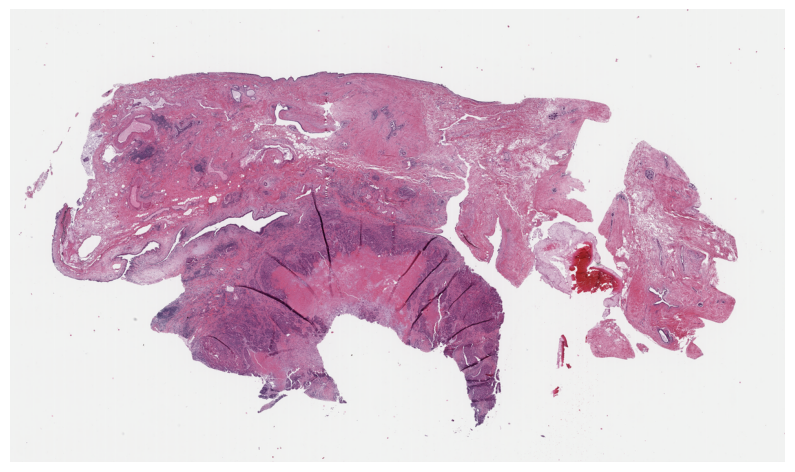

In [157]:
from PIL import Image
import matplotlib.pyplot as plt

thumbnail = slide.get_thumbnail((1200, 1200))

plt.figure(figsize=(10, 10))
plt.imshow(thumbnail)
plt.axis("off");

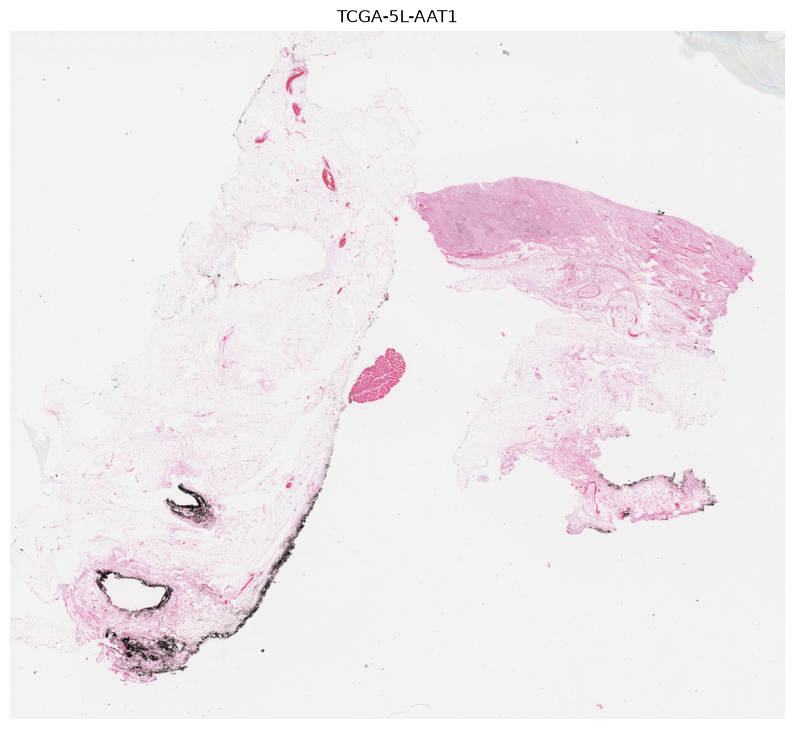

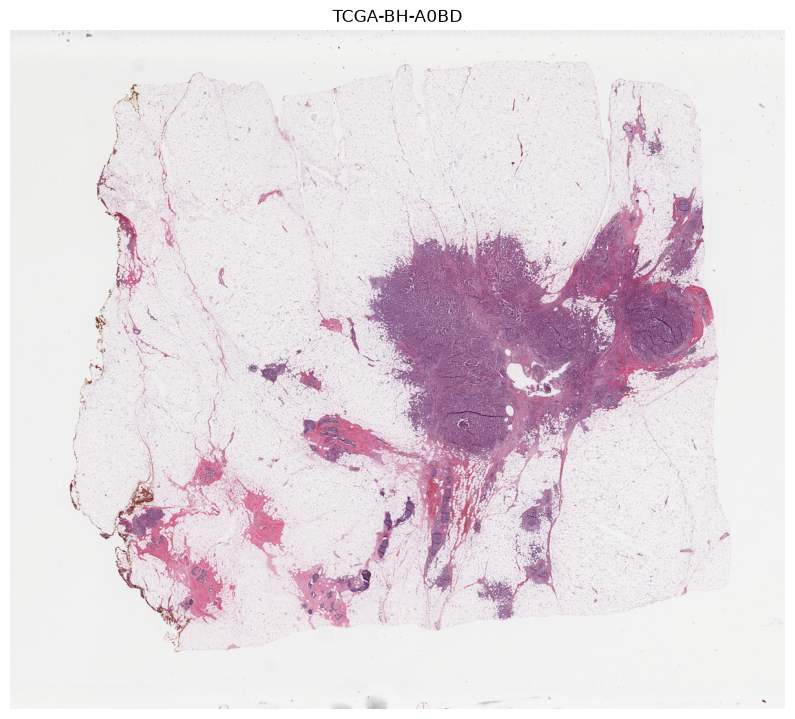

In [158]:
# Open the other two WSIs

for patient in ["TCGA-5L-AAT1", "TCGA-BH-A0BD"]:
    wsi_path = [p for p in wsi_files if patient in p.name][0]
    slide_other = openslide.OpenSlide(str(wsi_path))

    thumbnail = slide_other.get_thumbnail((1200, 1200))

    plt.figure(figsize=(10, 10))
    plt.imshow(thumbnail)
    plt.title(patient)
    plt.axis("off");